# Ximenez: Parse

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
# pd.set_option('display.max_colwidth', False)

In [30]:
src_id = 'ximenez'

# Source to TEMA_TOKEN and LINE

In [31]:
xml_lines = open("xom-all-flat-mod-pnums.xml").readlines()

In [32]:
els = dict(
    lang = '',
    folio = 0,
    side = 0,
    para_num = 0,
    lb = 0,
    # lb_n  = '' # Line number as given
)

data = []
ana_list = []

for line in xml_lines:
    
    # Grab column (lang) 
    # Pattern: <div xml:lang="quc" type="column" rend="left half">
    if re.match(r"<div xml:lang", line):
        els['lang'] = line.split('"')[1].split('"')[0]
        els['para_num'] = 0

    # Grab manuscript
    if re.match(r"^<pb ", line):
        f, s = line.split("xom-")[1].split('"')[0].split('-')
        els['folio'] = int(f[1:])
        els['side'] = int(s[1:])
        els['lb'] = 0

    # Grab paragraph
    if re.match(r"^<p ", line):
        els['para_num'] += 1

    # Grab line break
    if re.match(r"^<lb n=", line):
        # els['lb_n'] = line.split('<lb n="')[1].split('"')[0]
        els['lb'] += 1
        els['lb_str'] = ' '.join(line.split("/>")[1:]).strip()
        
        # Grab RS elements
        ana_num = 0
        rs = line.split("<rs ")
        if len(rs) > 1:
            for r in rs[1:]:
                ana = r.split('"')[1]  
                ana_num += 1
                # ana_list.append((els['lang'], els['folio'], els['side'], els['para_num'], els['lb'], els['lb_n'], ana_num, ana))
                ana_list.append((els['lang'], els['folio'], els['side'], els['para_num'], els['lb'], ana_num, ana))

        data.append(tuple(els.values()))

In [33]:
ana_cols = list(els.keys())[:-1] + ['ana_num', 'ana_id']
TEMA_TOKEN = pd.DataFrame(ana_list, columns = ana_cols).set_index(ana_cols[:-1])
TEMA_TOKEN.sort_index()

ana_id
lang folio side para_num lb ana_num                 
quc  1     1    2        6  1        TINAMIT_K'ICHE'
                         10 1                TZ'AQOL
                            2                 B'ITOL
                         11 1                   ALOM
                            2               K'AJOLOM
...                                              ...
spa  56    2    100      29 1            NIM_CH'OKOJ
                         30 1        TINAMIT_K'ICHE'
                         31 1              POPOL_WUJ
                         34 1        TINAMIT_K'ICHE'
                            2             SANTA_CRUZ

[6109 rows x 1 columns]

In [34]:
LINE = pd.DataFrame(data, columns=els.keys())
LINE = LINE.set_index(['lang', 'folio', 'side', 'para_num', 'lb'])
assert LINE.index.has_duplicates == False, "LINE has duplicates"
LINE

lb_str
lang folio side para_num lb                                                   
quc  1     1    1        1            <hi rend="very-large">ARE V XE OHER</hi>
                         2                               Ꜩih varal Quiche vbi.
                2        3   <hi rend="large">V</hi>aral xchicaꜩibah vi xch...
                         4                    tiquiba vi oher ꜩih, vticaribal,
                         5                         vxenabal puch ronohel xban,
...                                                                        ...
spa  56    2    100      31  quiche</rs>. <choice><abbr>porq’</abbr><expan ...
                         32  yaun<choice><abbr>q’</abbr><expan instant="fal...
                         33   se ha perdído. y aquí seacabo todo lo<pc> –</pc>
                         34  tocante <rs ana="TINAMIT_K'ICHE'">al quiche</r...
                         35                                         Cruz.</rs>

[10177 rows x 1 columns]

**Clean line strings**

In [35]:
LINE['lb_str_plain'] = LINE.lb_str.str.replace(r"<[^>]+/?>", "", regex=True).str.replace(" –", "–", regex=False)
chars = {
    'Ꜩ': 'Tz',
    'ꜩ': 'tz',
    'ꜫ': "q'",
    'ÿ': 'i', # 'ij' 
}
for char in chars:
    LINE.lb_str_plain = LINE.lb_str_plain.str.replace(char, chars[char], regex=False)
LINE

lb_str  \
lang folio side para_num lb                                                      
quc  1     1    1        1            <hi rend="very-large">ARE V XE OHER</hi>   
                         2                               Ꜩih varal Quiche vbi.   
                2        3   <hi rend="large">V</hi>aral xchicaꜩibah vi xch...   
                         4                    tiquiba vi oher ꜩih, vticaribal,   
                         5                         vxenabal puch ronohel xban,   
...                                                                        ...   
spa  56    2    100      31  quiche</rs>. <choice><abbr>porq’</abbr><expan ...   
                         32  yaun<choice><abbr>q’</abbr><expan instant="fal...   
                         33   se ha perdído. y aquí seacabo todo lo<pc> –</pc>   
                         34  tocante <rs ana="TINAMIT_K'ICHE'">al quiche</r...   
                         35                                         Cruz.</rs>   

                                                           lb_str_plain  
lang folio side para_num lb                                              
quc  1     1    1        1                                ARE V XE OHER  
                         2                       Tzih varal Quiche vbi.  
                2        3                Varal xchicatzibah vi xchica–  
                         4            tiquiba vi oher tzih, vticaribal,  
                         5                  vxenabal puch ronohel xban,  
...                                                                 ...  
spa  56    2    100      31   quiche. porq’porque ya no ay donde leerlo  
                         32        yaunq’que antíguamente lo auía, pero  
                         33      se ha perdído. y aquí seacabo todo lo–  
                         34  tocante al quiche, q’que se llama StaSanta  
                         35                                       Cruz.  

[10177 rows x 2 columns]

# TEMA_TOKEN to PTM

In [36]:
PTM = TEMA_TOKEN.loc['quc']\
    .groupby(['para_num','ana_id']).ana_id.count()\
    .unstack(fill_value=0)
PTM

ana_id,AB'IX,ACHAQ'_IB'OY,AJ,AJACHE',AJAL_MES,AJAL_PUJ,AJAL_Q'ANA,AJAL_TOQ'OB,AJAQ_Q'ALEL_NJDOCE,AJAW_AJTZIK_WINAQ,...,XUXULIM_JA,XUXULUM_JA,YA'XKANUL,YACHWACH,YAK,YAKI,YAKI_TEPEW,YAKOLATAM,YAKOLATAM_UTZA'M_POP_SAQLATOL,YOLKWAT_KITZALKWAT
para_num,,,,,,,,,,,,,,,,,,,,,
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
94,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
95,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
# sns.clustermap(PTM.T.corr(), col_cluster=False, cmap="Spectral", center=0, metric='euclidean', method='ward', cbar_pos=None);

In [38]:
# sns.heatmap(PTM.T, cmap='Spectral', center=0);

# TEMA_TOKEN to TEMA

In [39]:
TEMA = TEMA_TOKEN.reset_index().value_counts(['lang','ana_id']).sort_index()\
    .to_frame('n').unstack(fill_value=0)
TEMA.columns = TEMA.columns.droplevel(0)
TEMA = TEMA.T 
TEMA['label'] = TEMA.apply(lambda x: x.name.replace('_', ' ').title(), axis=1)
TEMA

lang,quc,spa,label
ana_id,,,
AB'IX,18,17,Ab'Ix
ACHAQ'_IB'OY,1,1,Achaq' Ib'Oy
AJ,8,10,Aj
AJACHE',2,2,Ajache'
AJAL_MES,3,3,Ajal Mes
...,...,...,...
YAKI,5,4,Yaki
YAKI_TEPEW,1,1,Yaki Tepew
YAKOLATAM,1,1,Yakolatam


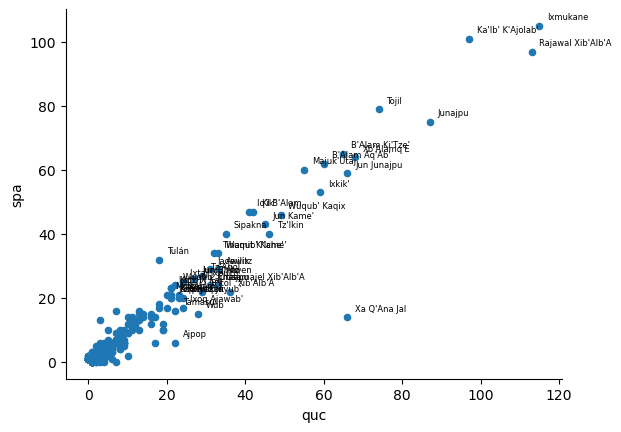

In [40]:
ax = TEMA.plot.scatter('quc', 'spa')
for i, row in TEMA[(TEMA.quc > 20) | (TEMA.spa > 20)].iterrows():
    ax.annotate(TEMA.loc[i].label, xy=(row['quc']+2, row['spa']+2), fontsize=6)
sns.despine()
plt.show()

# TEMAS over narrative time

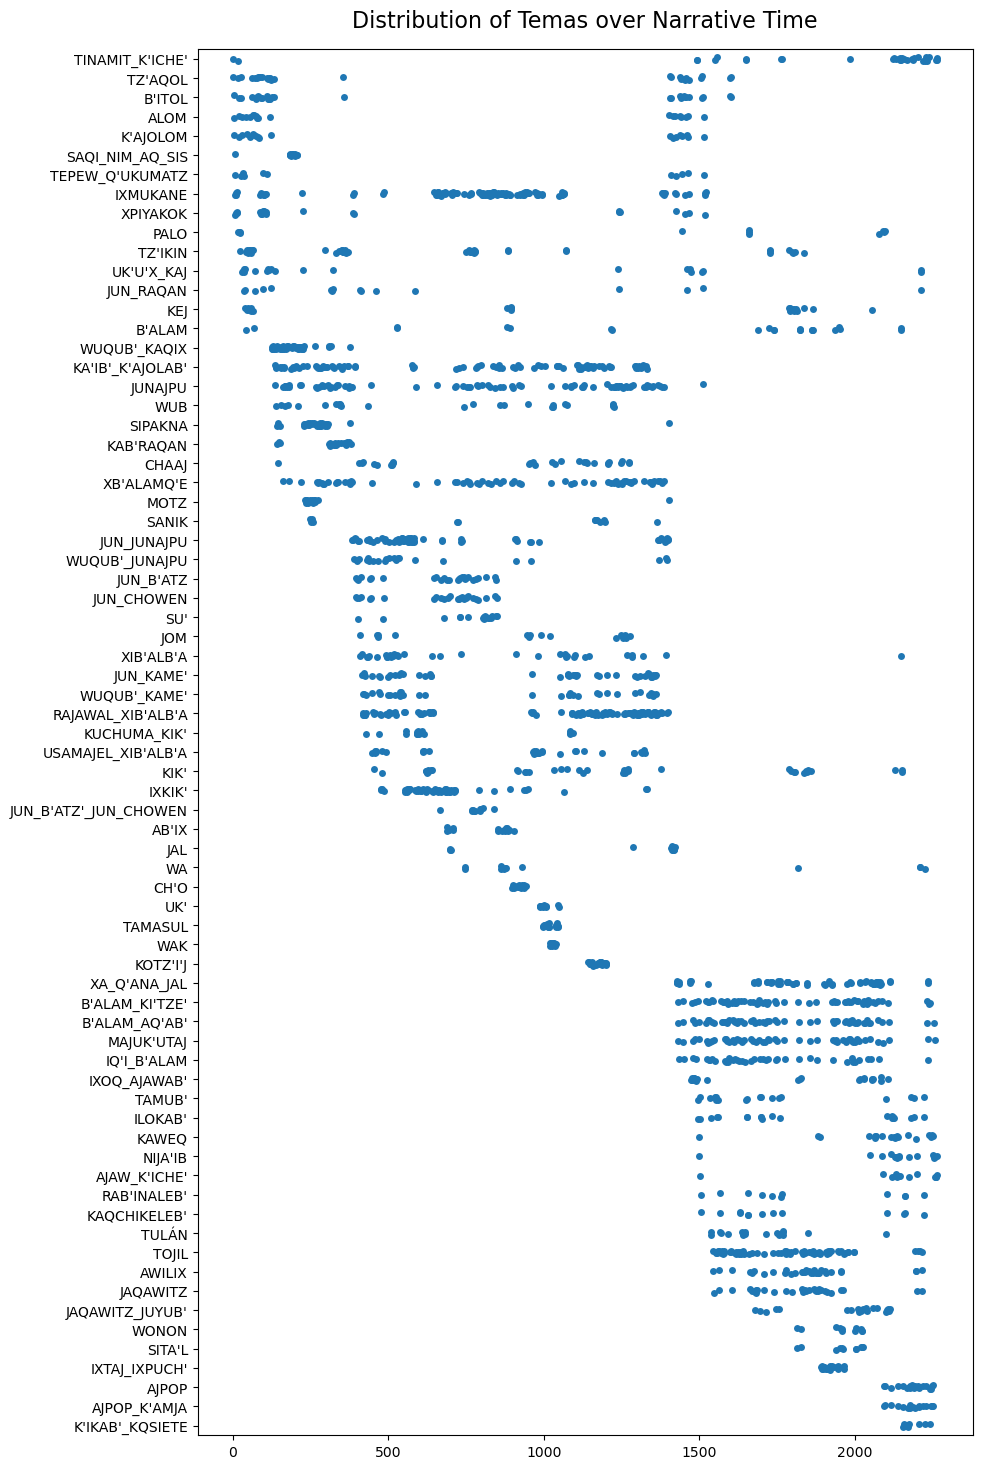

In [13]:
TEMA_TOKEN_QUC = TEMA_TOKEN.loc['quc']
min_n = 10
IDX = TEMA.loc[TEMA['quc'] > min_n].index
X = TEMA_TOKEN_QUC[TEMA_TOKEN_QUC.ana_id.isin(IDX)]
h = len(IDX) // 4
fig, ax = plt.subplots(figsize=(10, h))
sns.stripplot(x=X.reset_index().index, y=X.ana_id, ax=ax)
plt.xlabel("")
plt.ylabel("")
plt.title("Distribution of Temas over Narrative Time", fontsize=16, y=1.01)
plt.savefig("xom-temas-over-time.png")
plt.savefig("xom-temas-over-time.svg")
plt.show()

# LINE to PARA (DOC)

In [55]:
LINE_QUC = LINE.loc['quc']
PARA = LINE_QUC.groupby(['para_num']).lb_str_plain.apply(lambda x: ' '.join(map(str,x))).to_frame('para_str')
PARA.para_str = PARA.para_str.str.replace(r"– ", "")
PARA['para_str_norm'] = PARA.para_str\
    .str.lower()\
    .str.replace(r"[,.:;?\"'+]", "", regex=True)\
    .str.replace(r"\d+", "", regex=True)\
    .str.replace(r"[()]", "", regex=True)
PARA['len'] = PARA.para_str_norm.str.len()
PARA

,para_str,para_str_norm,len
para_num,,,
1,ARE V XE OHER Tzih varal Quiche vbi.,are v xe oher tzih varal quiche vbi,35
2,Varal xchicatzibah vi xchicatiquiba vi oher tz...,varal xchicatzibah vi xchicatiquiba vi oher tz...,1168
3,"ARE V TzIHOXIC VAE Cacatzinin oc, caca chamam ...",are v tzihoxic vae cacatzinin oc caca chamam o...,106
4,Vae cute nabe tzih nabe vchan. mahabi oq' hun ...,vae cute nabe tzih nabe vchan mahabi oq hun vi...,696
5,Ta xpe cut vtzih varal xul cuq ri tepeu gucuma...,ta xpe cut vtzih varal xul cuq ri tepeu gucuma...,1649
...,...,...,...
93,Arecut nim ha ri chuvach nihaibab are vbinaam ...,arecut nim ha ri chuvach nihaibab are vbinaam ...,162
94,Are chicut rech ahau qui che va vmam vcahau Ma...,are chicut rech ahau qui che va vmam vcahau ma...,150
95,Arecut ahauab ri chuvach ahau quiche are vleel...,arecut ahauab ri chuvach ahau quiche are vleel...,292


# PARA to TOKEN

In [58]:
TOKEN = PARA.para_str_norm.str.split(expand=True).stack().to_frame('term_str')
TOKEN.index.names = PARA.index.names + ['token_num']
TOKEN

term_str
para_num token_num            
1        0                 are
         1                   v
         2                  xe
         3                oher
         4                tzih
...                        ...
97       39         chiconohel
         40             quiche
         41           stasanta
         42               cruz
         43                vbi

[25926 rows x 1 columns]

# TOKEN to DTM

In [59]:
DTM = TOKEN.groupby(['para_num', 'term_str']).term_str.count().unstack(fill_value=0)
DTM

term_str,a,ab,abah,abanel,abanoh,abi,abix,abixic,abixom,ac,...,zul,zutz,zutzil,zuy,çu,ɛaɛ,ɛaɛche,‘qumal,ꜭ,ꜭahol
para_num,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
94,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
95,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# DTM to VOCAB

In [60]:
VOCAB = DTM.sum().to_frame('n')
VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
VOCAB['i'] = np.log2(1/VOCAB.p)
VOCAB['h'] = VOCAB.p * VOCAB.i
VOCAB

,n,p,i,h
term_str,,,,
a,51,0.001967,8.989687,0.017684
ab,1,0.000039,14.662112,0.000566
abah,24,0.000926,10.077150,0.009329
abanel,1,0.000039,14.662112,0.000566
abanoh,1,0.000039,14.662112,0.000566
...,...,...,...,...
ɛaɛ,2,0.000077,13.662112,0.001054
ɛaɛche,2,0.000077,13.662112,0.001054
‘qumal,1,0.000039,14.662112,0.000566


# TOKEN to CHUNK

In [61]:
n_chunks = 60

TOKEN['chunk_num'] = pd.cut(TOKEN.reset_index().index, n_chunks, labels=[x for x in range(n_chunks)])
TOKEN

term_str chunk_num
para_num token_num                      
1        0                 are         0
         1                   v         0
         2                  xe         0
         3                oher         0
         4                tzih         0
...                        ...       ...
97       39         chiconohel        59
         40             quiche        59
         41           stasanta        59
         42               cruz        59
         43                vbi        59

[25926 rows x 2 columns]

In [62]:
CHUNK = TOKEN.groupby('chunk_num', observed=True).term_str.apply(lambda x: ' '.join(x)).to_frame('chunk_str')
CHUNK.head()

,chunk_str
chunk_num,
0,are v xe oher tzih varal quiche vbi varal xchi...
1,hupacha ta cha uaxoc ta caquiro puch apachinac...
2,chic qui bil quib maui mixutzin v bixic cabi r...
3,camul qaholom nimac nima tziz ah cuval ah yama...
4,che abah xqhauic ronohel qui quebalquixot qui ...


Add associated paragraph numbers to chapters.

In [63]:
CHUNK['doc_ids'] = LINE.join(TOKEN).join(CHUNK, on="chunk_num")\
    .reset_index()\
    .value_counts(['chunk_num', 'para_num'])\
    .sort_index()\
    .reset_index().groupby('chunk_num', observed=True)\
    .para_num.apply(lambda x: " ".join(map(str, x)))
CHUNK.head()

,chunk_str,doc_ids
chunk_num,,
0,are v xe oher tzih varal quiche vbi varal xchi...,1 2 3 4 5
1,hupacha ta cha uaxoc ta caquiro puch apachinac...,5 6 7
2,chic qui bil quib maui mixutzin v bixic cabi r...,7 8
3,camul qaholom nimac nima tziz ah cuval ah yama...,8 9
4,che abah xqhauic ronohel qui quebalquixot qui ...,9 10


# TOKEN to CTM

In [64]:
CTM = TOKEN.groupby(['chunk_num', 'term_str'], observed=True).term_str.count().unstack(fill_value=0)
CTM.head()

term_str,a,ab,abah,abanel,abanoh,abi,abix,abixic,abixom,ac,...,zul,zutz,zutzil,zuy,çu,ɛaɛ,ɛaɛche,‘qumal,ꜭ,ꜭahol
chunk_num,,,,,,,,,,,,,,,,,,,,,
0,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Choose SIGS

In [65]:
DP = CTM / CTM.sum()
DI = np.log2(1/DP).replace(np.inf, 0)
DH = DP * DI
VOCAB['dh'] = DH.sum()
VOCAB

,n,p,i,h,dh
term_str,,,,,
a,51,0.001967,8.989687,0.017684,4.931750
ab,1,0.000039,14.662112,0.000566,0.000000
abah,24,0.000926,10.077150,0.009329,3.907268
abanel,1,0.000039,14.662112,0.000566,0.000000
abanoh,1,0.000039,14.662112,0.000566,0.000000
...,...,...,...,...,...
ɛaɛ,2,0.000077,13.662112,0.001054,0.000000
ɛaɛche,2,0.000077,13.662112,0.001054,0.000000
‘qumal,1,0.000039,14.662112,0.000566,0.000000


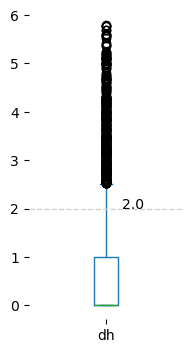

In [66]:
ax = VOCAB.dh.plot.box(figsize=(2,4))
vline = VOCAB.dh.quantile(.9).round(2)
ax.axhline(vline, ls='--', lw=1, c='lightgray')
ax.annotate(vline, xy=(1.1,2))
sns.despine(left=True, bottom=True)
plt.show()

In [67]:
dh_thresh = vline

sig_mask = VOCAB.dh > dh_thresh
SIGS = VOCAB[sig_mask].index
len(VOCAB), len(SIGS)

(5617, 518)

In [68]:
SIGS = VOCAB.sort_values('dh').tail(500).index

# CTM to TFIDF

In [69]:
TF = CTM[SIGS]
DF = TF[TF > 0].sum()
IDF = np.log((n_chunks+1)/(DF+1)+1)
TFIDF = TF * IDF
L2_norm = np.sqrt((TFIDF**2).sum(1))
TFIDF_L2 = TFIDF.div(L2_norm, axis=0)

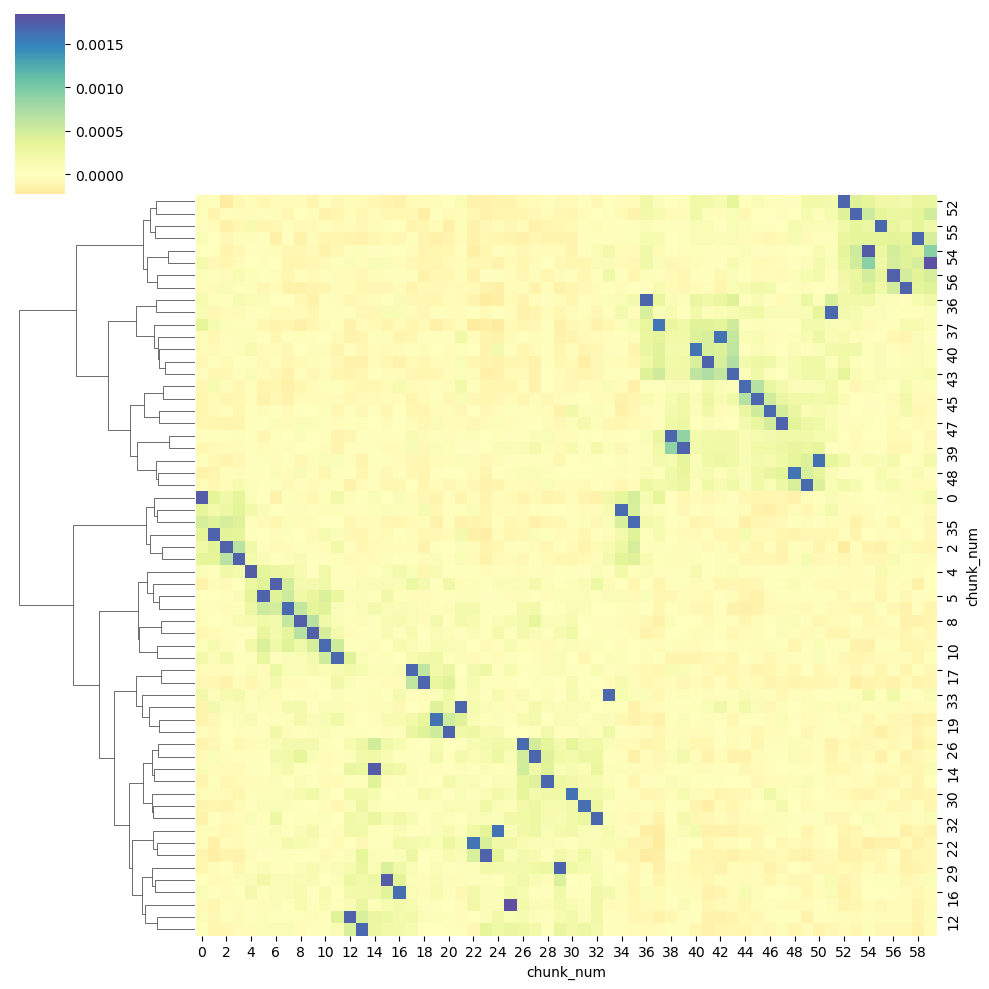

In [70]:
sns.clustermap(TFIDF_L2.T.cov(), cmap="Spectral", center=0, col_cluster=None, 
    metric='euclidean',
    method='ward')
plt.show()

# Save

In [71]:
TOKEN.to_csv(f"{src_id}-TOKEN.csv", index=True)
VOCAB.to_csv(f"{src_id}-VOCAB.csv", index=True)
LINE.to_csv(f"{src_id}-LINE.csv", index=True)
CHUNK.to_csv(f"{src_id}-CHUNK-{n_chunks}.csv", index=True)
TFIDF_L2.to_csv(f"{src_id}-TFIDF-{n_chunks}.csv", index=True)

In [72]:
for lang in ['spa', 'quc']:
    LINE.loc[lang].to_csv(f"ximenez-{lang}-LINE.csv", index=True, sep='|')
    TEMA_TOKEN.loc[lang].to_csv(f"ximenez-{lang}-TEMA_TOKEN.csv", index=True, sep='|')
    
TEMA.to_csv(f"ximenez-{lang}-TEMA.csv", index=True, sep='|')